In [2]:
import sys
sys.path.append("anomaly-detection/diffusion-anomaly")
sys.path.append("anomaly-detection/diffusion-anomaly/scripts")

import argparse
import os
from torch.autograd import Variable
from guided_diffusion.bratsloader import BRATSDataset
import blobfile as bf
import torch as th
os.environ['OMP_NUM_THREADS'] = '8'

import torch.distributed as dist
import torch.nn.functional as F
from torch.nn.parallel.distributed import DistributedDataParallel as DDP
from torch.optim import AdamW
# from visdom import Visdom
import numpy as np
# viz = Visdom(port=8850, server="sbndbuild03.fnal.gov")
# loss_window = viz.line( Y=th.zeros((1)).cpu(), X=th.zeros((1)).cpu(), opts=dict(xlabel='epoch', ylabel='Loss', title='classification loss'))
# val_window = viz.line( Y=th.zeros((1)).cpu(), X=th.zeros((1)).cpu(), opts=dict(xlabel='epoch', ylabel='Loss', title='validation loss'))
# acc_window= viz.line( Y=th.zeros((1)).cpu(), X=th.zeros((1)).cpu(), opts=dict(xlabel='epoch', ylabel='acc', title='accuracy'))

from guided_diffusion import dist_util, logger
from guided_diffusion.fp16_util import MixedPrecisionTrainer
from guided_diffusion.image_datasets import load_data, ShuffleDataset
from guided_diffusion.train_util import visualize
from guided_diffusion.resample import create_named_schedule_sampler
from guided_diffusion.script_util import (
    add_dict_to_argparser,
    args_to_dict,
    classifier_and_diffusion_defaults,
    create_classifier_and_diffusion,
)
from guided_diffusion.train_util import parse_resume_step_from_filename, log_loss_dict
from scripts.classifier_train import compute_top_k

from matplotlib import pyplot as plt

/home/munjung/.conda/envs/diffusion/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
args = {
    "lr": 1e-4,
    "batch_size": 10,
    "image_size": 512,
    "classifier_attention_resolutions": "16,32",
    "classifier_depth": 4,
    "classifier_width": 32,
    "classifier_pool": "attention",
    "classifier_resblock_updown": True,
    "classifier_use_scale_shift_norm": False,
    "classifier_use_fp16": False,
    "learn_sigma": False,
    "diffusion_steps": 1000,
    "noise_schedule": "linear",
    "timestep_respacing": "",
    "use_kl": False,
    "predict_xstart": False,
    "predict_xprev": False,
    "rescale_timesteps": False,
    "rescale_learned_sigmas": False,
    "dataset": "",
    "data_dir": "/scratch/7DayLifetime/munjung/anomaly-detection/npz",

}

In [4]:
dist_util.setup_dist()
logger.configure()

logger.log("creating model and diffusion...")
model, diffusion = create_classifier_and_diffusion(
    **{k: v for k, v in args.items() if k in classifier_and_diffusion_defaults()},
)
model.to(dist_util.dev())
# if args.noised:
#     schedule_sampler = create_named_schedule_sampler(
#         args.schedule_sampler, diffusion, maxt=1000
#     )

model_name = "/home/munjung/anomaly-detection/diffusion-anomaly/results/classifier_model_005000.pt"
logger.log(
    f"loading model from checkpoint: {model_name}..."
)
model.load_state_dict(
    dist_util.load_state_dict(
        model_name, map_location=dist_util.dev()
    )
)

# Needed for creating correct EMAs and fp16 parameters.
dist_util.sync_params(model.parameters())

port2 52693
Logging to ./results
creating model and diffusion...
timestepresp2 
number_in_channels classifier 1
pool attention
steps 1000 [1000]
predict_xstart False
predict_xprev False
model_mean_type ModelMeanType.EPSILON
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 1

In [5]:
charge_scale = 1.

In [25]:
os.listdir(args["data_dir"])
# path = args["data_dir"]+"/healthy" + "/tpc1_plane0_rec_82090893_277.npz"
path = "/scratch/7DayLifetime/gputnam/raw-sq-wtruth" + "/tpc1_plane0_rec_82090893_277.npz"
# path = args["data_dir"]+"/erase/" + "tpc1_plane0_rec_67583145_78_diseased_erase.npz"

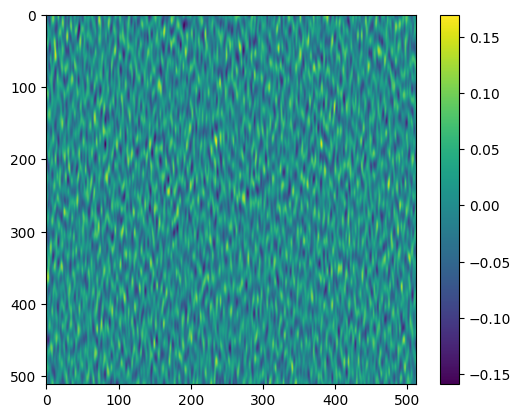

tensor([7.6935], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1436, -4.5494]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


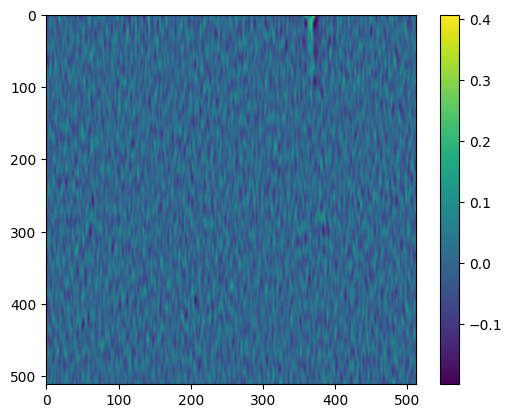

tensor([7.5991], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1076, -4.4910]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


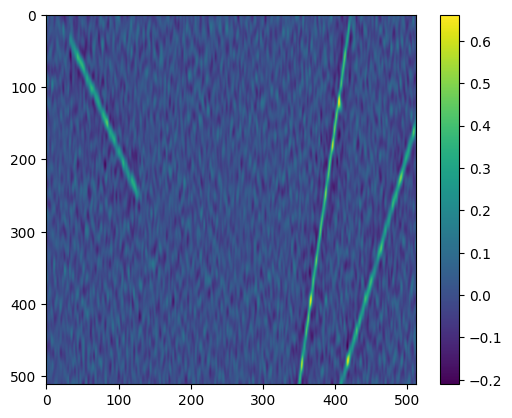

tensor([7.5924], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1051, -4.4869]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


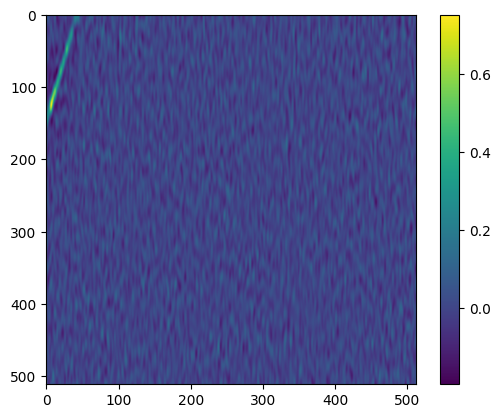

tensor([7.5450], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.0864, -4.4580]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


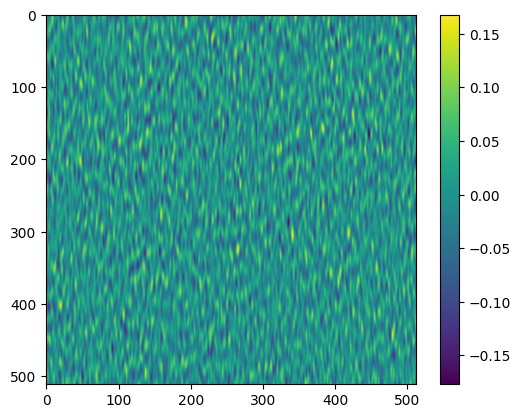

tensor([7.6868], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1410, -4.5454]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


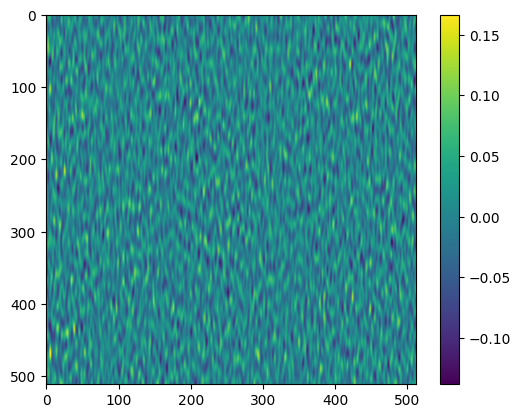

tensor([7.7048], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1474, -4.5569]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


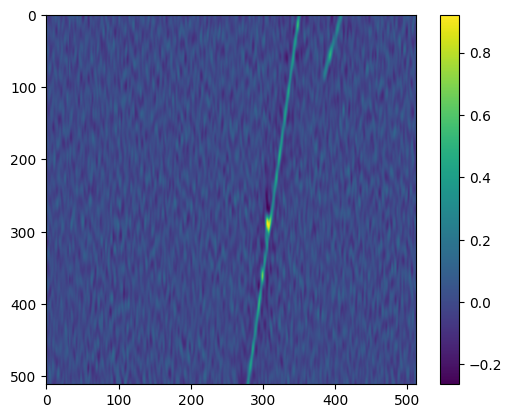

tensor([7.4695], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.0581, -4.4108]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


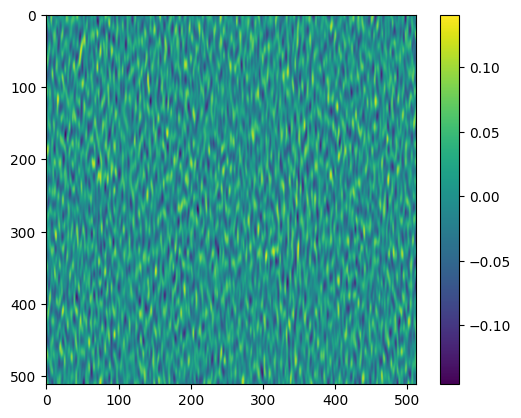

tensor([7.6910], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1421, -4.5484]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


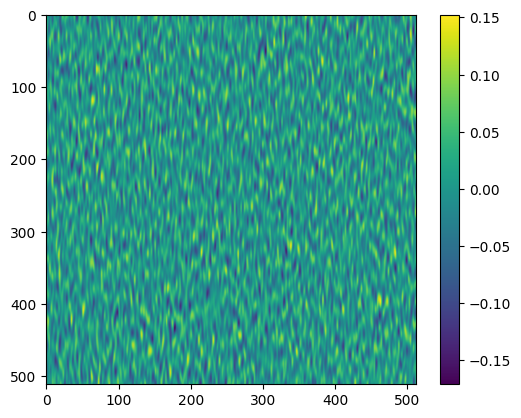

tensor([7.7048], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1475, -4.5569]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


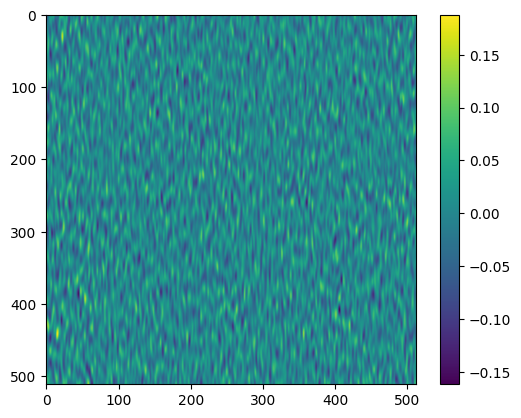

tensor([7.7189], device='cuda:0', grad_fn=<NllLossBackward0>)
tensor([[ 3.1529, -4.5655]], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([1], device='cuda:0')


In [26]:
name=str(path).split("/")[-1].split(".")[0]
numpy_img = np.load(path)
_cache_file = visualize(numpy_img["reco"]).astype(np.float32)
# _cache_file = numpy_img["reco"].astype(np.float32)
_cache_fname = name
_cache_true = numpy_img["truth"].astype(np.float32)

# weight by sum of true charge
_weights = np.sum(_cache_true, axis=(1, 2, 3)).astype(np.float32)
_weights = _weights / np.mean(_weights)

charge_norm = np.mean(_cache_true)
_pixel_weights = 1 + _cache_true / charge_norm / charge_scale
_pixel_weights = _pixel_weights / np.mean(_pixel_weights)
_charge = np.sum(_cache_true, axis=(1, 2, 3)).astype(np.float32)

# img_idx = 1
for img_idx in range(10):
    arr = _cache_file[img_idx]
    w = _weights[img_idx]
    pw = _pixel_weights[img_idx]
    c = _charge[img_idx]

    plt.imshow(arr[0]) #, vmin=-100, vmax=100)
    plt.colorbar()
    plt.show()

    batch = th.from_numpy(np.array([arr])).to(dist_util.dev()).float()
    labels = th.from_numpy(np.array([1])).to(dist_util.dev()).long()

    t = th.zeros(batch.shape[0], dtype=th.long, device=dist_util.dev())
    logits = model(batch, timesteps=t)
    loss = F.cross_entropy(logits, labels, reduction="none")
    print(loss)
    print(logits)
    print(labels)
    compute_top_k(logits, labels, 1, reduction="none")

In [51]:
# append two arrays along the first dimension
_cache_file_2 = np.concatenate([_cache_file, _cache_file], axis=0)
_cache_file_2.shape

(320, 1, 512, 512)

In [56]:
_cache_file.shape
# _cache_file.transpose(1, 0, 2, 3).shape

(160, 1, 512, 512)

In [ ]:
# set random seed 